## `Identificação de oportunidades de cross-sell em varejo usando regras de associação`

- Notebook Autor: [Enio Rubens][1]
- Projeto: Identificação de oportunidades de cross-sell em varejo usando regras de associação
 
[1]: https://github.com/eniorubens/enioRubens_dataScienceProjects

Este projeto aplica Análise de Cesta de Compras para identificar padrões de coocorrência entre produtos em transações de varejo. O objetivo é encontrar associações que possam apoiar estratégias de cross-sell, organização de layout e recomendação de produtos.

A questão central é distinguir combinações realmente associadas de combinações apenas frequentes, evitando conclusões equivocadas baseadas somente na popularidade dos itens.

In [1]:
# Autor : Enio Rubens
#
# Cientista de Dados
__author__ = 'Enio Rubens'

### `Iniciação de Parâmetros`

In [2]:
import pandas as pd 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Remove warnings
import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

In [3]:
# Plot settings
sns.set_theme(style="ticks")
mpl.rcParams['figure.dpi'] = 96
mpl.rcParams['figure.figsize'] = (13.33,6.5)

# Title
mpl.rcParams['figure.titlesize'] = 22
mpl.rcParams['figure.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 22
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlepad'] = 20

# Axes labels
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.labelweight'] = 'bold'

# Grid and thicks
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.left'] = False
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.grid'] = False
mpl.rcParams['axes.grid.axis'] = 'y'
#mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams['ytick.left'] = False

# Legend
mpl.rcParams['legend.facecolor'] = 'w'
mpl.rcParams['legend.title_fontsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['legend.frameon'] = True
mpl.rcParams['legend.framealpha'] = 1
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['legend.facecolor'] = 'white'
mpl.rcParams['legend.edgecolor'] = 'gray'
mpl.rcParams['legend.borderpad'] = 0.6

# Other
mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['lines.markersize'] = 10
#mpl.rcParams['scatter.edgecolors'] = None

pd.set_option('display.max_rows', 3000)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 2000)
pd.options.display.max_colwidth = 1000

### Inicialização do Dataset

Utilizamos o dataset disponível no Kaggle:
https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset

O conjunto de dados possui três colunas principais:

- **Member_number:** identificador único do cliente  
- **Date:** data da transação  
- **itemDescription:** descrição do item adquirido  

Essas variáveis permitem reconstruir as transações por cliente e por data, formando a base necessária para a aplicação da Análise de Cesta de Compras.

In [4]:
import os
for dirname, _, filenames in os.walk('./dataset/'):
    for filename in filenames:
        display(os.path.join(dirname, filename))

'./dataset/Groceries_dataset.csv'

In [5]:
# Load transactions from pandas.
def read_data()->pd.DataFrame:
    return pd.read_csv("./dataset/Groceries_dataset.csv")
    
transaction = read_data()    
transaction.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


### `Preparação dos Dados`

Os dados foram agregados por cliente e por data, de forma a representar cada transação como um conjunto de itens adquiridos.

Em seguida, os dados foram transformados em uma matriz binária (one-hot encoding), onde cada linha representa uma transação e cada coluna representa a presença ou ausência de um item.

Esse formato é necessário para a aplicação do algoritmo Apriori.

In [6]:
# Take a look at dataset
transactions = transaction.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).reset_index()
transactions.head(6)

,Member_number,Date,itemDescription
0,1000,15-03-2015,"[sausage, whole milk, semi-finished bread, yogurt]"
1,1000,24-06-2014,"[whole milk, pastry, salty snack]"
2,1000,24-07-2015,"[canned beer, misc. beverages]"
3,1000,25-11-2015,"[sausage, hygiene articles]"
4,1000,27-05-2015,"[soda, pickled vegetables]"
5,1001,02-05-2015,"[frankfurter, curd]"


In [7]:
# Retrieve data from the item description column and convert it to a list
transactions = transactions['itemDescription'].tolist()
transactions[:6]

[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['whole milk', 'pastry', 'salty snack'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles'],
 ['soda', 'pickled vegetables'],
 ['frankfurter', 'curd']]

[['salsicha', 'leite integral', 'pão semiacabado', 'iogurte'],
  ['leite integral', 'pastelaria', 'lanche salgado'],
  ['cerveja em lata', 'misc. bebidas'],
  ['salsicha', 'artigos de higiene'],
  ['refrigerante', 'legumes em conserva'],
  ['Hot-dog', 'coalhada']]

In [8]:
# Count the number of transactions with sausage and whole milk
sausage = transactions.count(['sausage', 'whole milk'])

# Count the number of transactions with whole milk and pastry
whole_milk = transactions.count(['whole milk', 'pastry'])

# Count the number of transactions with sausage and hygiene articles
hygiene_articles = transactions.count(['sausage','hygiene articles'])

# Print the counts for each transaction.
print(f'''
Sausage with whole milk         : {sausage}
Whole milk with pastry          : {whole_milk}
Sausage with hygiene articles   : {hygiene_articles}'''
)


Sausage with whole milk         : 37
Whole milk with pastry          : 14
Sausage with hygiene articles   : 2


#### `Regras de Associação`
As regras de associação são compostas por dois elementos principais:
- Antecedente (A): conjunto de itens de origem
- Consequente (B): conjunto de itens associados

Uma regra pode ser representada como:

{A} → {B}

Indicando que a presença de A em uma transação aumenta a probabilidade de ocorrência de B.

Neste projeto, foram consideradas principalmente regras simples (um antecedente e um consequente), visando maior interpretabilidade e aplicabilidade em contexto de negócio.


#### `Seleção de Regras Relevantes`
A geração de regras de associação pode resultar em um grande volume de combinações, muitas das quais não apresentam relevância prática.

Por isso, é necessário aplicar critérios de filtragem para identificar regras úteis, considerando:
- suporte mínimo
- confiança mínima
- lift maior que 1

Esses critérios permitem eliminar regras pouco representativas ou estatisticamente irrelevantes.

#### `Métricas de Avaliação`
As principais métricas utilizadas na análise são:
- **Support (Suporte)** : Frequência de ocorrência de um item ou conjunto de itens no total de transações.
- **Confidence (Confiança)** : Probabilidade de ocorrência do consequente dado o antecedente.
- **Lift**: Mede o quanto a ocorrência conjunta de A e B difere do esperado sob independência.
    - Lift > 1: associação positiva
    - Lift = 1: independência
    - Lift < 1: associação negativa
- **Conviction**: Mede o grau de dependência da regra considerando a direção da associação.
- **Zhang’s Metric**: Avalia a força da associação em escala de -1 a 1, sendo útil para identificar relações mais robustas.

#### `Considerações Importantes`
Regras com alto suporte indicam itens frequentes, mas não necessariamente associações relevantes.

Por isso, a análise deve priorizar regras com lift superior a 1, que indicam relações mais fortes do que o esperado ao acaso.


### `Transformação em matriz binária` 
One-hot

In [9]:
# Import the transaction encoder function from mlxtend
from mlxtend.preprocessing import TransactionEncoder
import numpy as np

# Instantiate transaction encoder and identify unique items in transactions
encoder = TransactionEncoder().fit(transactions)

# One-hot encode transactions
onehot = encoder.transform(transactions)

# Convert one-hot encoded data to DataFrame
onehot = pd.DataFrame(onehot, columns = encoder.columns_)

# Print the one-hot encoded transaction dataset
onehot.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,beverages,bottled beer,bottled water,brandy,brown bread,butter,butter milk,cake bar,candles,candy,canned beer,canned fish,canned fruit,canned vegetables,cat food,cereals,chewing gum,chicken,chocolate,chocolate marshmallow,citrus fruit,cleaner,cling film/bags,cocoa drinks,coffee,condensed milk,cooking chocolate,cookware,cream,cream cheese,curd,curd cheese,decalcifier,dental care,dessert,detergent,dish cleaner,dishes,dog food,domestic eggs,female sanitary products,finished products,fish,flour,flower (seeds),flower soil/fertilizer,frankfurter,frozen chicken,frozen dessert,frozen fish,frozen fruits,frozen meals,frozen potato products,frozen vegetables,fruit/vegetable juice,grapes,hair spray,ham,hamburger meat,hard cheese,herbs,honey,house keeping products,hygiene articles,ice cream,instant coffee,jam,ketchup,kitchen towels,kitchen utensil,light bulbs,liqueur,liquor,liquor (appetizer),liver loaf,long life bakery product,make up remover,male cosmetics,margarine,mayonnaise,meat,meat spreads,misc. beverages,mustard,napkins,newspapers,nut snack,nuts/prunes,oil,onions,organic products,organic sausage,other vegetables,packaged fruit/vegetables,pasta,pastry,pet care,photo/film,pickled vegetables,pip fruit,popcorn,pork,pot plants,potato products,preservation products,processed cheese,prosecco,pudding powder,ready soups,red/blush wine,rice,roll products,rolls/buns,root vegetables,rubbing alcohol,rum,salad dressing,salt,salty snack,sauces,sausage,seasonal products,semi-finished bread,shopping bags,skin care,sliced cheese,snack products,soap,soda,soft cheese,softener,soups,sparkling wine,specialty bar,specialty cheese,specialty chocolate,specialty fat,specialty vegetables,spices,spread cheese,sugar,sweet spreads,syrup,tea,tidbits,toilet cleaner,tropical fruit,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,Fa

### `Cálculo do suporte`

O suporte representa a frequência com que um item ou conjunto de itens aparece no total de transações.

Essa métrica é utilizada para identificar itens relevantes e serve como base para a geração de itemsets frequentes no algoritmo Apriori.

In [16]:
# Compute the support
support = onehot.mean().sort_values(ascending=False)

# Print the support
support.head(10).round(4)

whole milk          0.1579
other vegetables    0.1221
rolls/buns          0.1100
soda                0.0971
yogurt              0.0859
root vegetables     0.0696
tropical fruit      0.0678
bottled water       0.0607
sausage             0.0603
citrus fruit        0.0531
dtype: float64

>Os resultados mostram que produtos de alta frequência, como leite integral e outros vegetais, aparecem em diversas transações, mas isso não implica necessariamente associação forte. Em várias combinações frequentes, o lift permanece abaixo de 1, sugerindo que a coocorrência observada pode ser explicada principalmente pela popularidade individual dos itens.

### `Aplicação do Apriori`
Aplicação do Apriori sobre presença/ausência dos itens

In [11]:
# Add a whole milk + other vegetables column to the DataFrame onehot
support_1 = np.logical_and(onehot['whole milk'], onehot['other vegetables']).mean()

# Add a whole milk + rolls/buns column to the DataFrame onehot
support_2 = np.logical_and(onehot['whole milk'], onehot['rolls/buns']).mean()

# Add a whole milk + yogurt column to the DataFrame onehot
support_3 = np.logical_and(onehot['whole milk'], onehot['yogurt']).mean()

# Print support values
print(f'''
whole milk and other vegetables : {support_1:.4f}
whole milk and rolls/buns       : {support_2:.4f}
whole milk and yogurt           : {support_3:.4f}
''')


whole milk and other vegetables : 0.0148
whole milk and rolls/buns       : 0.0140
whole milk and yogurt           : 0.0112



>Regras com suporte elevado são úteis para identificar produtos com grande presença operacional no carrinho, mas decisões de cross-selling devem priorizar regras com lift superior a 1, pois elas indicam associação acima do esperado ao acaso.

>Produtos muito populares podem funcionar como itens-base de operação, mas nem sempre representam as melhores oportunidades promocionais. Já regras com maior lift podem ser mais úteis para bundles, recomendações contextuais e posicionamento conjunto de produtos.

In [12]:
# Compute support for whole milk and other vegetables (both)
supportB = np.logical_and(onehot['whole milk'], onehot['other vegetables']).mean()

# Compute support for whole milk
supportWM = onehot['whole milk'].mean()

# Compute support for other vegetables
supportOV = onehot['other vegetables'].mean()

# Compute confidence for both rules
confidenceWM = supportB / supportWM
confidenceOV = supportB / supportOV

# Print results
print(f'''
Confidence for whole milk       : {confidenceWM:.2f} 
Confidence for other vegetables : {confidenceOV:.2f}''')


Confidence for whole milk       : 0.09 
Confidence for other vegetables : 0.12


In [13]:
# Compute support for beef and butter milk
supportPT = np.logical_and(onehot['whole milk'], onehot['other vegetables']).mean()

# Compute support for whole milk
supportWM = onehot['whole milk'].mean()

# Compute support for other vegetables
supportOV = onehot['other vegetables'].mean()

# Compute lift
lift = supportPT / (supportWM * supportOV)

# Print lift
print("Lift: %.2f" % lift)

Lift: 0.77


In [14]:
# Compute support for whole milk AND other vegetables
supportPH = np.logical_and(onehot['whole milk'], onehot['other vegetables']).mean()

# Compute support for whole milk
supportP = onehot['whole milk'].mean()

# Compute support for NOT other vegetables
supportnH = 1.0 - onehot['other vegetables'].mean()

# Compute support for whole milk and NOT other vegetables
supportPnH = supportP - supportPH

# Compute and print conviction for whole milk -> other vegetables
conviction = supportP * supportnH / supportPnH
print("Conviction: %.2f" % conviction)

Conviction: 0.97


#### `Métrica de Zhang`

A métrica de Zhang varia de -1 a 1 e mede a força da associação entre antecedente e consequente.

- Valores próximos de **1** indicam associação positiva forte
- Valores próximos de **0** indicam associação fraca ou inexistente
- Valores próximos de **-1** indicam dissociação


In [ ]:
# Compute the support of whole milk and  other vegetables
supportT = onehot['whole milk'].mean()
supportP = onehot['other vegetables'].mean()

# Compute the support of both onehot
supportTP = np.logical_and(onehot['whole milk'], onehot['other vegetables']).mean()

# Complete the expressions for the numerator and denominator
numerator = supportTP - supportT*supportP
denominator = max(supportTP*(1-supportT), supportT*(supportP-supportTP))

# Compute and print Zhang's metric
zhang = numerator / denominator

print("Zhang : %.4f" % zhang)

Zhang : -0.2625


>No exemplo analisado, o valor negativo sugere que a ocorrência conjunta dos itens é inferior ao que seria esperado sob uma associação positiva, indicando uma relação fraca ou desfavorável.

In [ ]:
def flatten_extend(matrix):
    flat_list = []
    for row in matrix:
        flat_list.extend(row)
    return flat_list

transactions_flatten = flatten_extend(transactions)
print(f'Quantas transações : {len(transactions_flatten)}')
print(f'Quantos itens : {len(set(transactions_flatten))}')
display(transactions_flatten[:10])

Quantas transações : 38765
Quantos itens : 167


['sausage',
 'whole milk',
 'semi-finished bread',
 'yogurt',
 'whole milk',
 'pastry',
 'salty snack',
 'canned beer',
 'misc. beverages',
 'sausage']

### `Apriori`

O algoritmo Apriori é utilizado para identificar conjuntos de itens frequentes a partir da matriz binária de transações.

Sua lógica se baseia na propriedade de que todos os subconjuntos de um itemset frequente também precisam ser frequentes.

In [ ]:
import scipy.special

# the dance
duo  = int(scipy.special.binom(167, 2))
trio = int(scipy.special.binom(167, 3))
quartet = int(scipy.special.binom(167, 4))

print(
f'''
Com nosso dataset de 38765 itens, temos:
- 1 itemset: O conjunto nulo, desprovido de itens.
- {len(set(transactions_flatten))} itemsets: Um item apenas.
- Aproximadamente {duo} itemsets: Em dupla.
- Quase {trio} itemsets: em trio.
- Quase {quartet} itemsets: quarteto.
''')


Com nosso dataset de 38765 itens, temos:
- 1 itemset: O conjunto nulo, desprovido de itens.
- 167 itemsets: Um item apenas.
- Aproximadamente 13861 itemsets: Em dupla.
- Quase 762355 itemsets: em trio.
- Quase 31256555 itemsets: quarteto.



### `Podas do Apriori`

O número de combinações possíveis cresce rapidamente com a quantidade de itens. Para lidar com isso, o algoritmo Apriori utiliza podas que eliminam combinações inviáveis nas etapas iniciais.

Isso reduz o custo computacional e mantém apenas itemsets com potencial analítico.

In [ ]:
# Import apriori from mlxtend
from mlxtend.frequent_patterns import apriori

# Compute frequent itemsets using the Apriori algorithm
frequent_itemsets = apriori(onehot, 
                            min_support = 0.006, 
                            max_len = 3, 
                            use_colnames = True)

frequent_itemsets['item'] = frequent_itemsets['itemsets']\
    .apply(lambda x: list(x)[0])

# Print a preview of the frequent itemsets
frequent_itemsets[['support', 'item']].head()
#print(frequent_itemsets.head())

,support,item
0,0.021386,UHT-milk
1,0.008087,baking powder
2,0.033950,beef
3,0.021787,berries
4,0.016574,beverages


### `Limiar de Support`

O limiar mínimo de suporte define a frequência mínima para que um itemset seja considerado relevante.

Valores altos reduzem o número de combinações, mas podem eliminar padrões úteis. Valores baixos aumentam a complexidade e introduzem ruído.


In [ ]:
# Compute frequent itemsets using a support of 0.003 and length of 3
frequent_itemsets_1 = apriori(onehot, min_support = 0.003, 
                            max_len = 3, use_colnames = True)

# Compute frequent itemsets using a support of 0.001 and length of 3
frequent_itemsets_2 = apriori(onehot, min_support = 0.001, 
                            max_len = 3, use_colnames = True)

# Print the number of freqeuent itemsets
print(len(frequent_itemsets_1), len(frequent_itemsets_2))

216 750


In [ ]:
frequent_itemsets_2['item'] = frequent_itemsets_2['itemsets'].apply(lambda x: list(x)[0])
frequent_itemsets_2[['support', 'item']].head(7)
#frequent_itemsets_2.head(7)

,support,item
0,0.004010,Instant food products
1,0.021386,UHT-milk
2,0.001470,abrasive cleaner
3,0.001938,artif. sweetener
4,0.008087,baking powder
5,0.001136,bathroom cleaner
6,0.033950,beef


### `Regras de Associação`

As regras de associação são compostas por dois elementos principais:

- **Antecedente (A)**
- **Consequente (B)**

Uma regra pode ser representada como:

A → B

Indicando que a presença de A aumenta a probabilidade de ocorrência de B.

Neste projeto, foram consideradas principalmente regras simples, visando maior interpretabilidade.


In [ ]:
# Import the association rule function from mlxtend
from mlxtend.frequent_patterns import association_rules, apriori

# Compute all association rules for frequent_itemsets_1
rules_1 = association_rules(frequent_itemsets_1, 
                            metric = "support", 
                         	min_threshold = 0.0015)

# Compute all association rules for frequent_itemsets_2
rules_2 = association_rules(frequent_itemsets_2, 
                            metric = 'support', 
                        	min_threshold = 0.0015)

# Print the number of association rules generated
print(len(rules_1), len(rules_2))

210 648


### `Métricas de Avaliação`

As principais métricas utilizadas são:

- **Support:** frequência de ocorrência do item ou itemset  
- **Confidence:** probabilidade de ocorrência do consequente dado o antecedente  
- **Lift:** mede o quanto a associação difere do esperado sob independência  
- **Conviction:** avalia a dependência direcional da regra  
- **Zhang’s Metric:** mede a força da associação em escala de -1 a 1  

In [ ]:
# Compute frequent itemsets using the Apriori algorithm
frequent_itemsets = apriori(onehot, min_support = 0.001, 
                           max_len = 2, use_colnames = True)

# Compute all association rules for frequent_itemsets
rules = association_rules(frequent_itemsets, 
                           metric = "lift", 
                           min_threshold = 1.0)

# Limpeza das regras de associação para visualização e análise

rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))

rules['antecedent_len'] = rules['antecedents'].apply(len)
rules['consequent_len'] = rules['consequents'].apply(len)

rules_clean = rules[
   [
      'antecedents_str',
      'consequents_str',
      'antecedent_len',
      'consequent_len',
      'support',
      'confidence',
      'lift',
      'conviction',
      'zhangs_metric'
   ]
].copy()

cols_metricas = ['support', 'confidence', 'lift', 'conviction', 'zhangs_metric']
rules_clean[cols_metricas] = rules_clean[cols_metricas].round(3)

rules_clean.head(10)



# Print association rules
#rules.head(10)

,antecedents_str,consequents_str,antecedent_len,consequent_len,support,confidence,lift,conviction,zhangs_metric
0,UHT-milk,tropical fruit,1,1,0.002,0.072,1.061,1.004,0.058
1,tropical fruit,UHT-milk,1,1,0.002,0.023,1.061,1.001,0.061
2,brown bread,beef,1,1,0.002,0.041,1.203,1.007,0.176
3,beef,brown bread,1,1,0.002,0.045,1.203,1.008,0.175
4,citrus fruit,beef,1,1,0.002,0.034,1.000,1.000,0.000
5,beef,citrus fruit,1,1,0.002,0.053,1.000,1.000,0.000
6,curd,beef,1,1,0.001,0.038,1.110,1.004,0.103
7,beef,curd,1,1,0.001,0.037,1.110,1.004,0.103
8,frozen vegetables,beef,1,1,0.001,0.045,1.336,1.012,0.259
9,beef,frozen vegetables,1,1,0.001,0.037,1.336,1.010,0.260


In [ ]:
# Compute frequent itemsets using the Apriori algorithm
frequent_itemsets = apriori(onehot, min_support = 0.0015, 
                        max_len=2, use_colnames = True)

# Compute all association rules using confidence
rules = association_rules(frequent_itemsets, 
                        metric = "confidence", 
                        min_threshold = 0.1)

rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
# Print association rules
rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,UHT-milk,other vegetables,0.021386,0.122101,0.002139,0.100000,0.818993,1.0,-0.000473,0.975443,-0.184234,0.015130,-0.025175,0.058758
1,UHT-milk,whole milk,0.021386,0.157923,0.002540,0.118750,0.751949,1.0,-0.000838,0.955549,-0.252105,0.014367,-0.046519,0.067416
2,beef,whole milk,0.033950,0.157923,0.004678,0.137795,0.872548,1.0,-0.000683,0.976656,-0.131343,0.024991,-0.023902,0.083709
3,berries,other vegetables,0.021787,0.122101,0.002673,0.122699,1.004899,1.0,0.000013,1.000682,0.004984,0.018930,0.000681,0.072297
4,berries,whole milk,0.021787,0.157923,0.002272,0.104294,0.660414,1.0,-0.001168,0.940127,-0.344543,0.012806,-0.063686,0.059341
5,beverages,other vegetables,0.016574,0.122101,0.001738,0.104839,0.858622,1.0,-0.000286,0.980716,-0.143419,0.012689,-0.019663,0.059535
6,beverages,soda,0.016574,0.097106,0.001871,0.112903,1.162678,1.0,0.000262,1.017808,0.142275,0.016736,0.017496,0.066087
7,beverages,whole milk,0.016574,0.157923,0.001938,0.116935,0.740459,1.0,-0.000679,0.953585,-0.262765,0.011232,-0.048674,0.064604
8,bottled beer,other vegetables,0.045312,0.122101,0.004678,0.103245,0.845568,1.0,-0.000854,0.978973,-0.160585,0.028747,-0.021479,0.070780
9,bottled beer,whole milk,0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549


In [ ]:
# Generate the initial set of rules using a minimum lift of 1.00
rules = association_rules(frequent_itemsets, metric = "lift", min_threshold = 1.00)

# Set antecedent support to 0.005
rules = rules[rules['antecedent support'] > 0.002]

# Set consequent support to 0.005
rules = rules[rules['consequent support'] > 0.002]

# Set the lower bound for Zhang's rule to 0.98
rules = rules[rules['zhangs_metric'] > 0.2]
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
6,beef,newspapers,0.033950,0.038896,0.001671,0.049213,1.265237,1.0,0.000350,1.010851,0.217002,0.023474,0.010734,0.046084
7,newspapers,beef,0.038896,0.033950,0.001671,0.042955,1.265237,1.0,0.000350,1.009409,0.218118,0.023474,0.009321,0.046084
10,sausage,beverages,0.060349,0.016574,0.001537,0.025471,1.536764,1.0,0.000537,1.009129,0.371714,0.020390,0.009046,0.059106
11,beverages,sausage,0.016574,0.060349,0.001537,0.092742,1.536764,1.0,0.000537,1.035704,0.355168,0.020390,0.034474,0.059106
20,brown bread,canned beer,0.037626,0.046916,0.002406,0.063943,1.362937,1.0,0.000641,1.018191,0.276701,0.029292,0.017866,0.057613
21,canned beer,brown bread,0.046916,0.037626,0.002406,0.051282,1.362937,1.0,0.000641,1.014394,0.279398,0.029292,0.014190,0.057613
32,canned beer,white bread,0.046916,0.023993,0.001537,0.032764,1.365573,1.0,0.000411,1.009068,0.280885,0.022158,0.008987,0.048415
33,white bread,canned beer,0.023993,0.046916,0.001537,0.064067,1.365573,1.0,0.000411,1.018325,0.274288,0.022158,0.017995,0.048415
40,curd,sausage,0.033683,0.060349,0.002941,0.087302,1.446615,1.0,0.000908,1.029531,0.319493,0.032282,0.028684,0.068014
41,sausage,curd,0.060349,0.033683,0.002941,0.048726,1.446615,1.0,0.000908,1.015814,0.328559,0.032282,0.015568,0.068014


### `Visualizando Regras de Associação`

A visualização das regras facilita a comparação entre métricas e ajuda a identificar padrões relevantes de forma mais intuitiva. Neste projeto, são utilizadas três abordagens principais: mapas de calor, gráficos de dispersão e coordenadas paralelas.

#### `Mapas de calor`

Os mapas de calor permitem observar a intensidade das associações entre antecedentes e consequentes com base em métricas como suporte, confiança e lift. Essa visualização é útil para identificar rapidamente combinações com maior destaque.

#### `Análise do lift`

O lift permite identificar associações que ocorrem acima do esperado ao acaso.

- Lift > 1 indica associação positiva  
- Lift = 1 indica independência  
- Lift < 1 indica ausência de relação relevante  

Essa métrica é essencial para diferenciar popularidade de associação real.

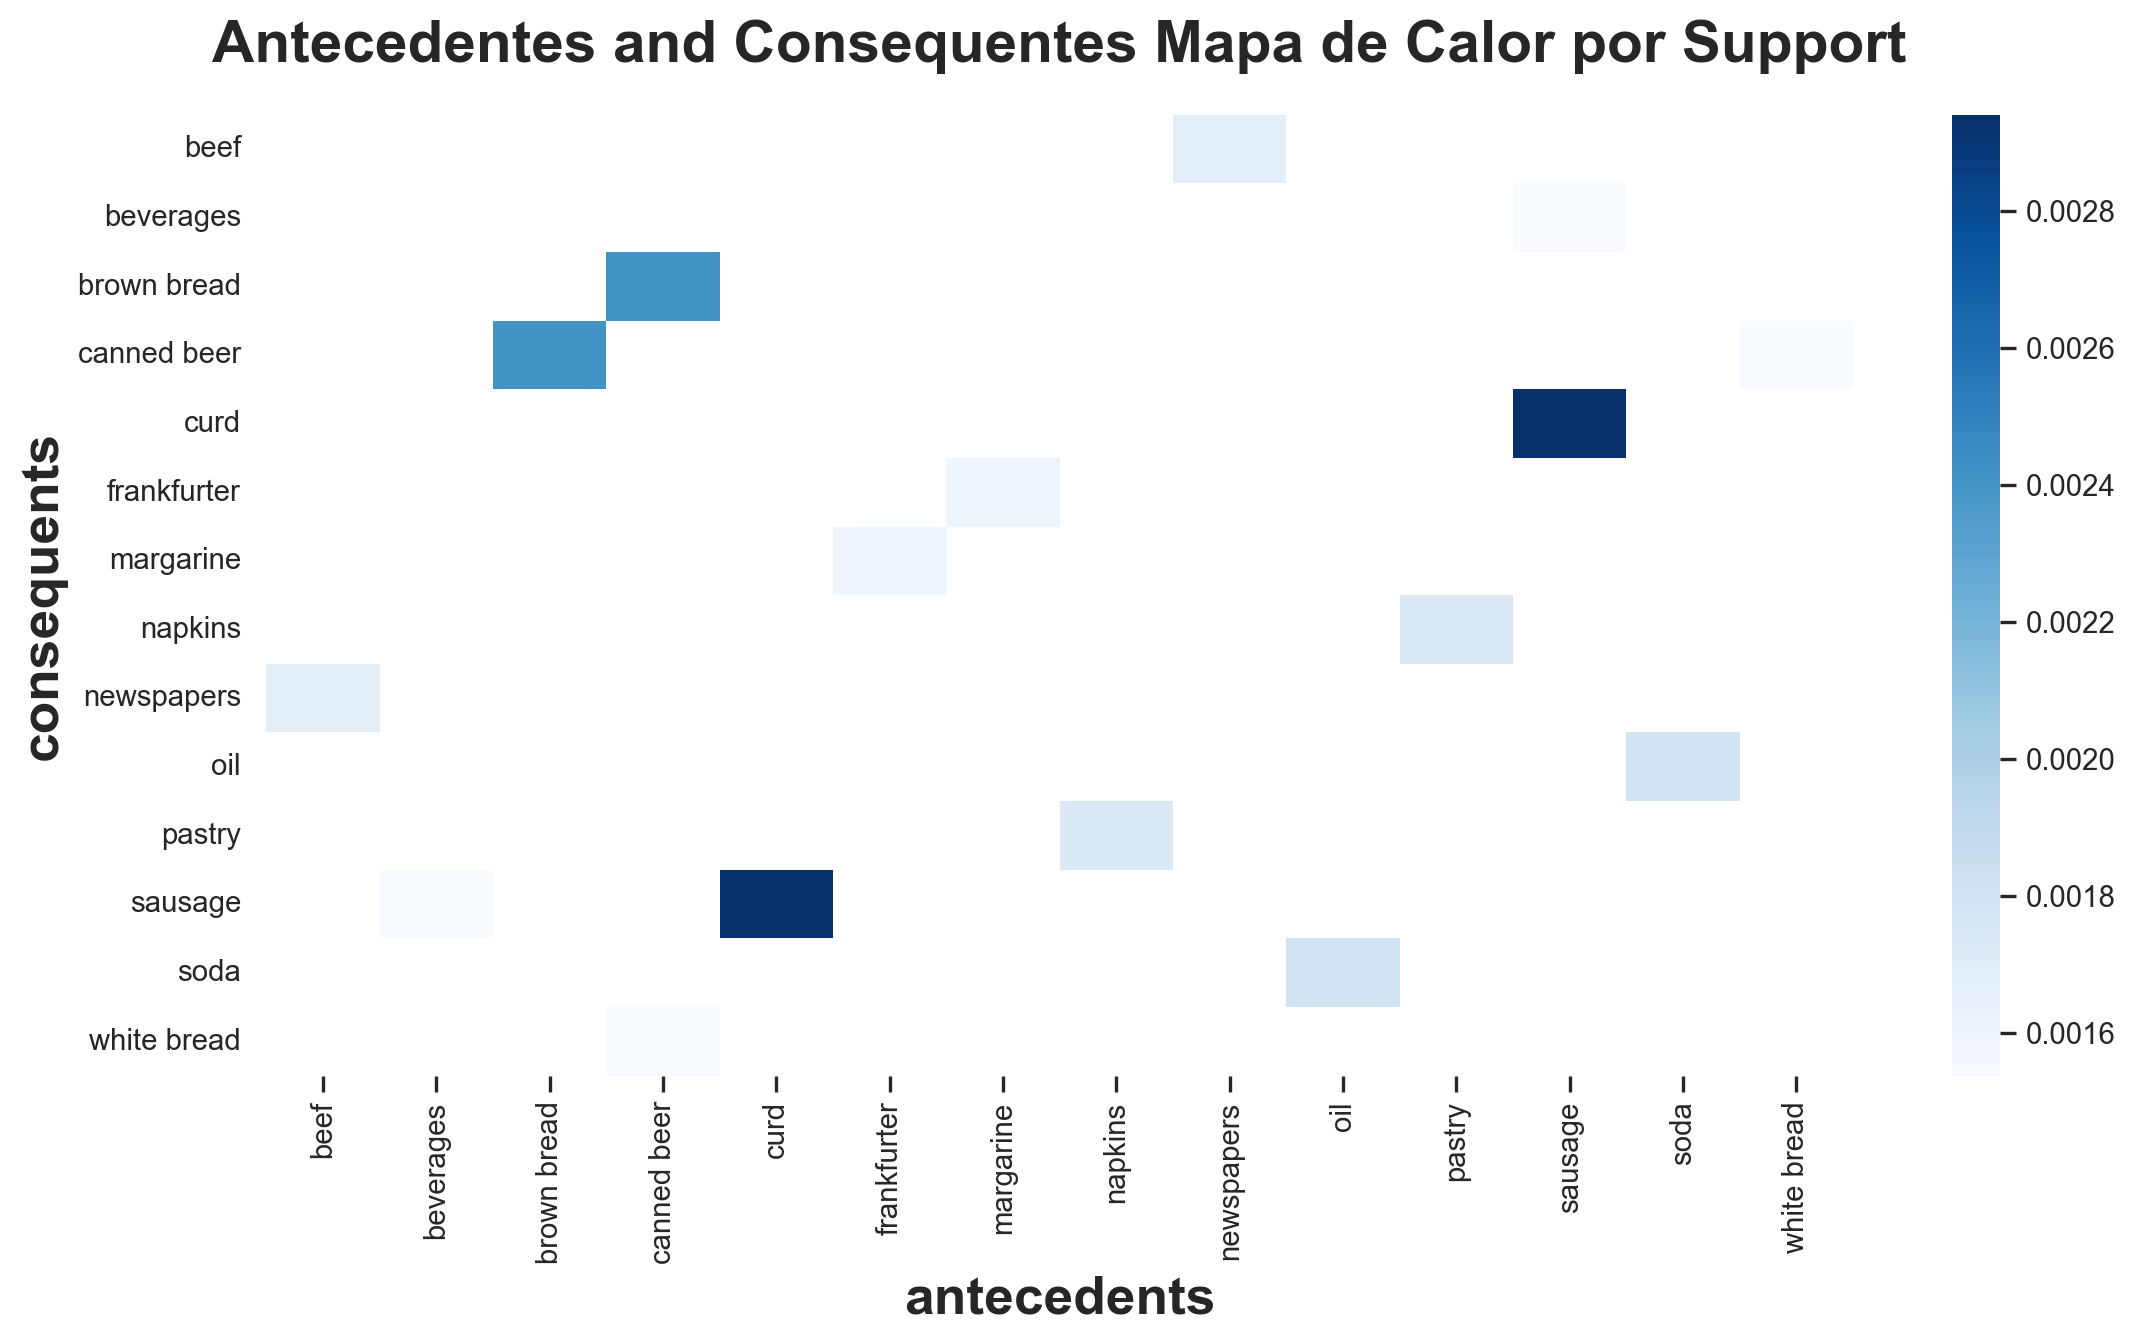

In [ ]:
# Replace frozen sets with strings
#rules['antecedents'] = rules['antecedents'].apply(lambda a: ','.join(list(a)))
#rules['consequents'] = rules['consequents'].apply(lambda a: ','.join(list(a)))

# Transform data to matrix format and generate heatmap
pivot = rules.pivot(index='consequents', columns='antecedents', values='support')
sns.heatmap(pivot, cmap="Blues")

# Title
plt.title('Antecedentes and Consequentes Mapa de Calor por Support')

# Format and display plot
plt.yticks(rotation=0)
plt.show()

### `Explorando o Lift com Mapas de Calor`
Voltamos nossa atenção para a métrica de lift para identificar as associações entre nossos produtos. O lift, com sua capacidade de revelar a força das co-ocorrências, para visualizar as relações, utilizamos novamente o mapa de calor, mas desta vez com foco no lift.


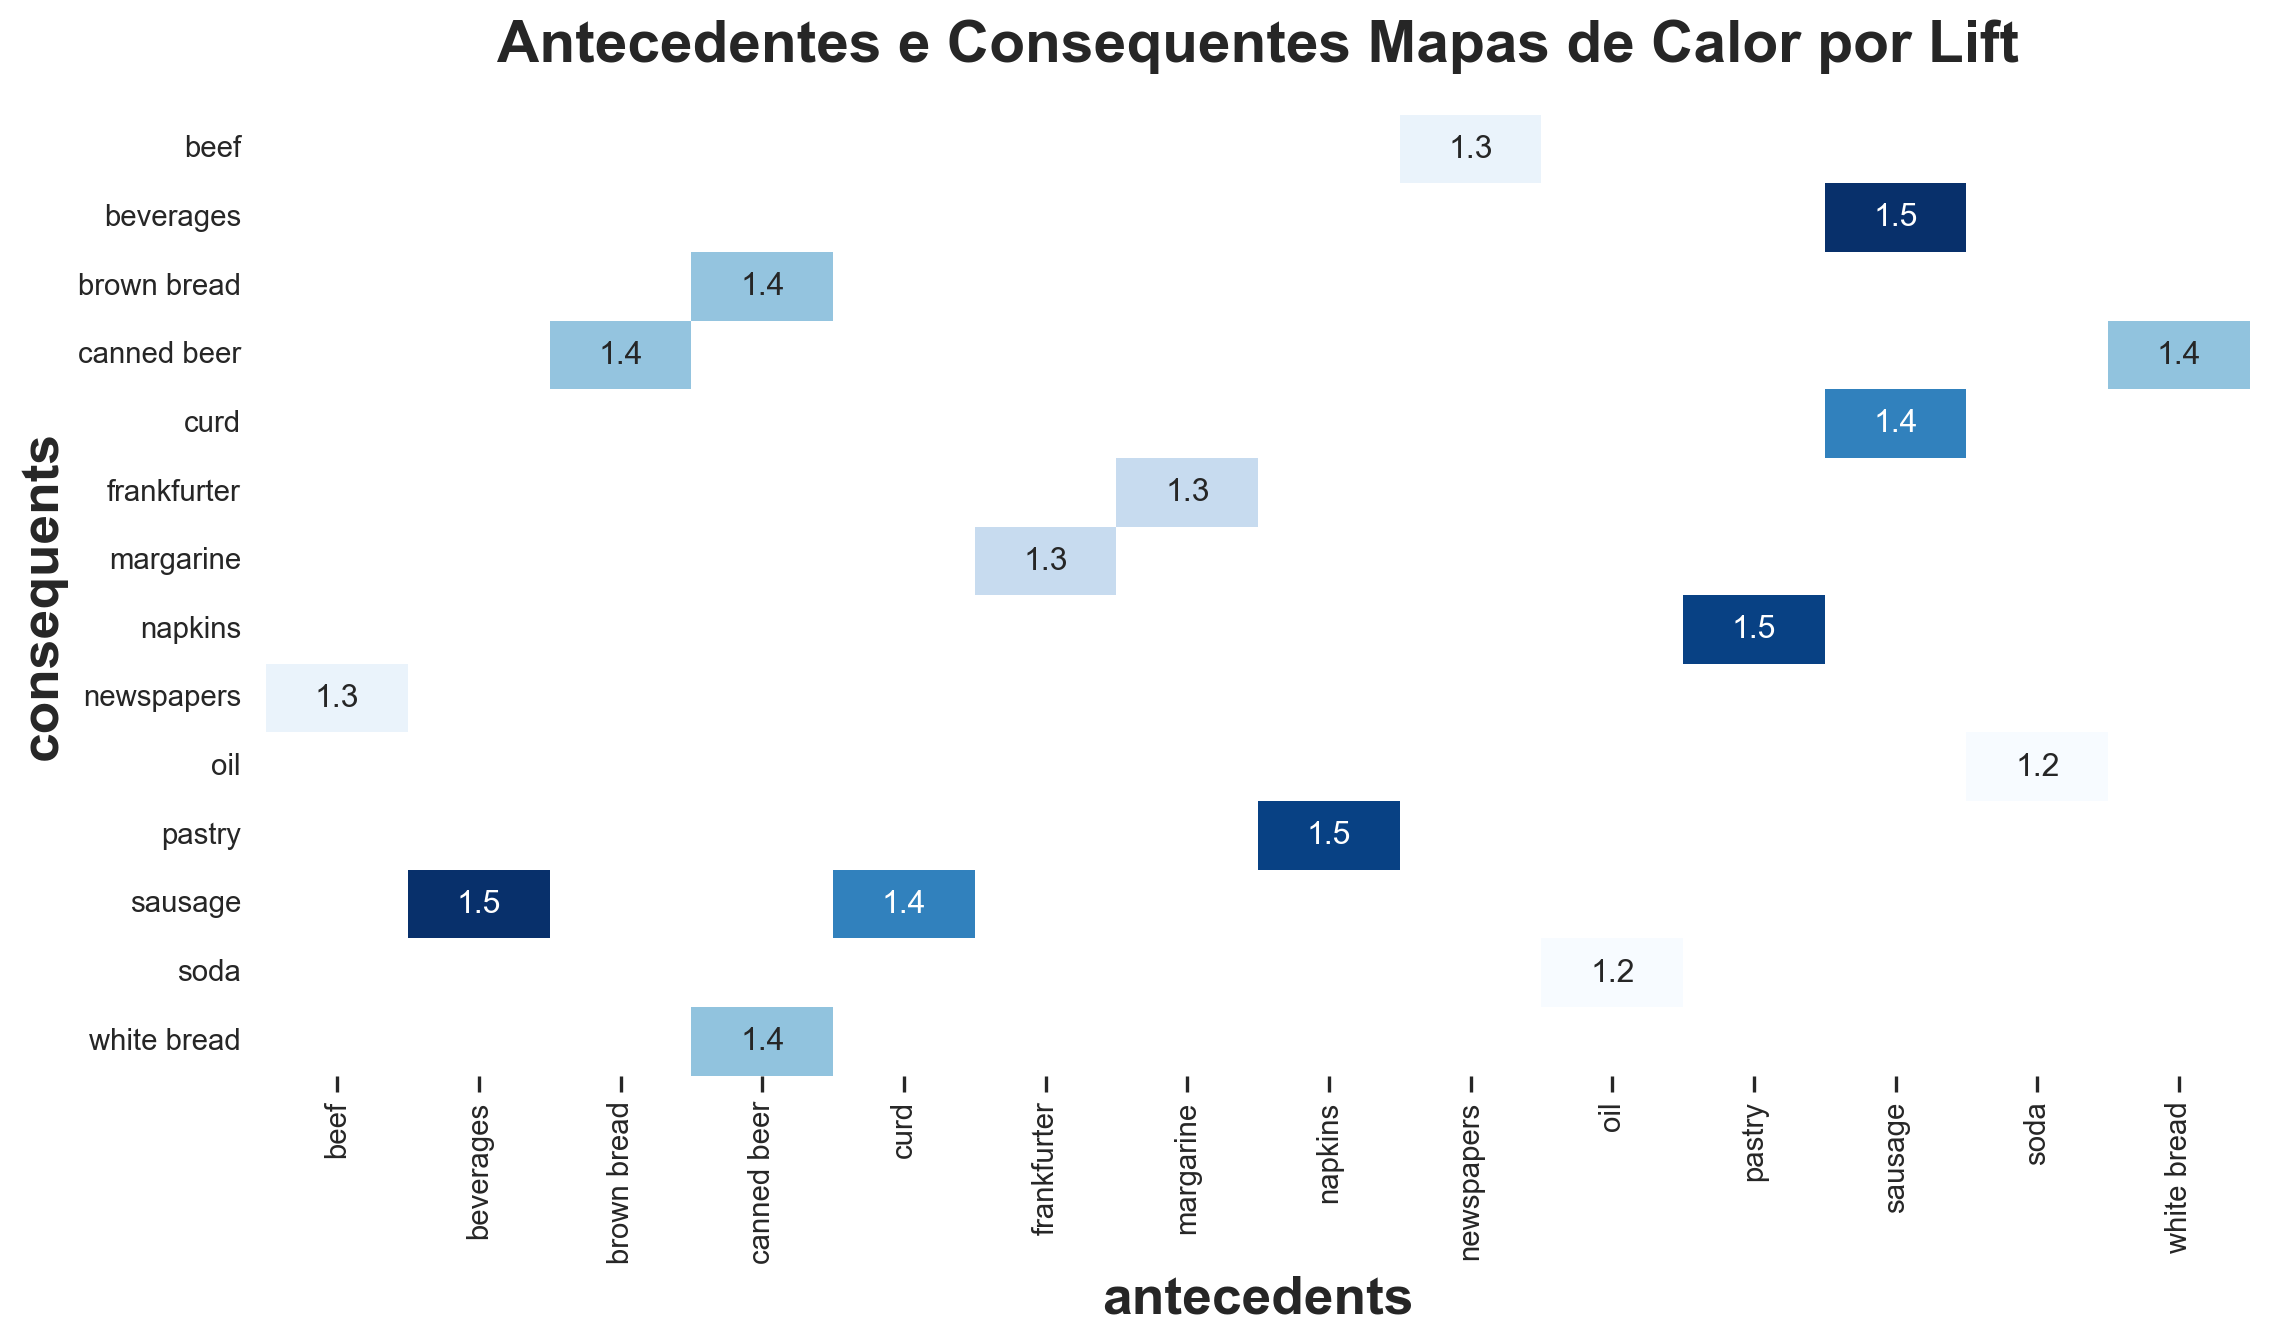

In [ ]:
# Transform the DataFrame of rules into a matrix using the lift metric
pivot = rules.pivot(index = 'consequents', 
                   columns = 'antecedents', values= 'lift')

# Generate a heatmap with annotations on and the colorbar off
sns.heatmap(pivot, annot = True, cbar=False, cmap="Blues")

# Title
plt.title('Antecedentes e Consequentes Mapas de Calor por Lift')

# Axis
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.show()

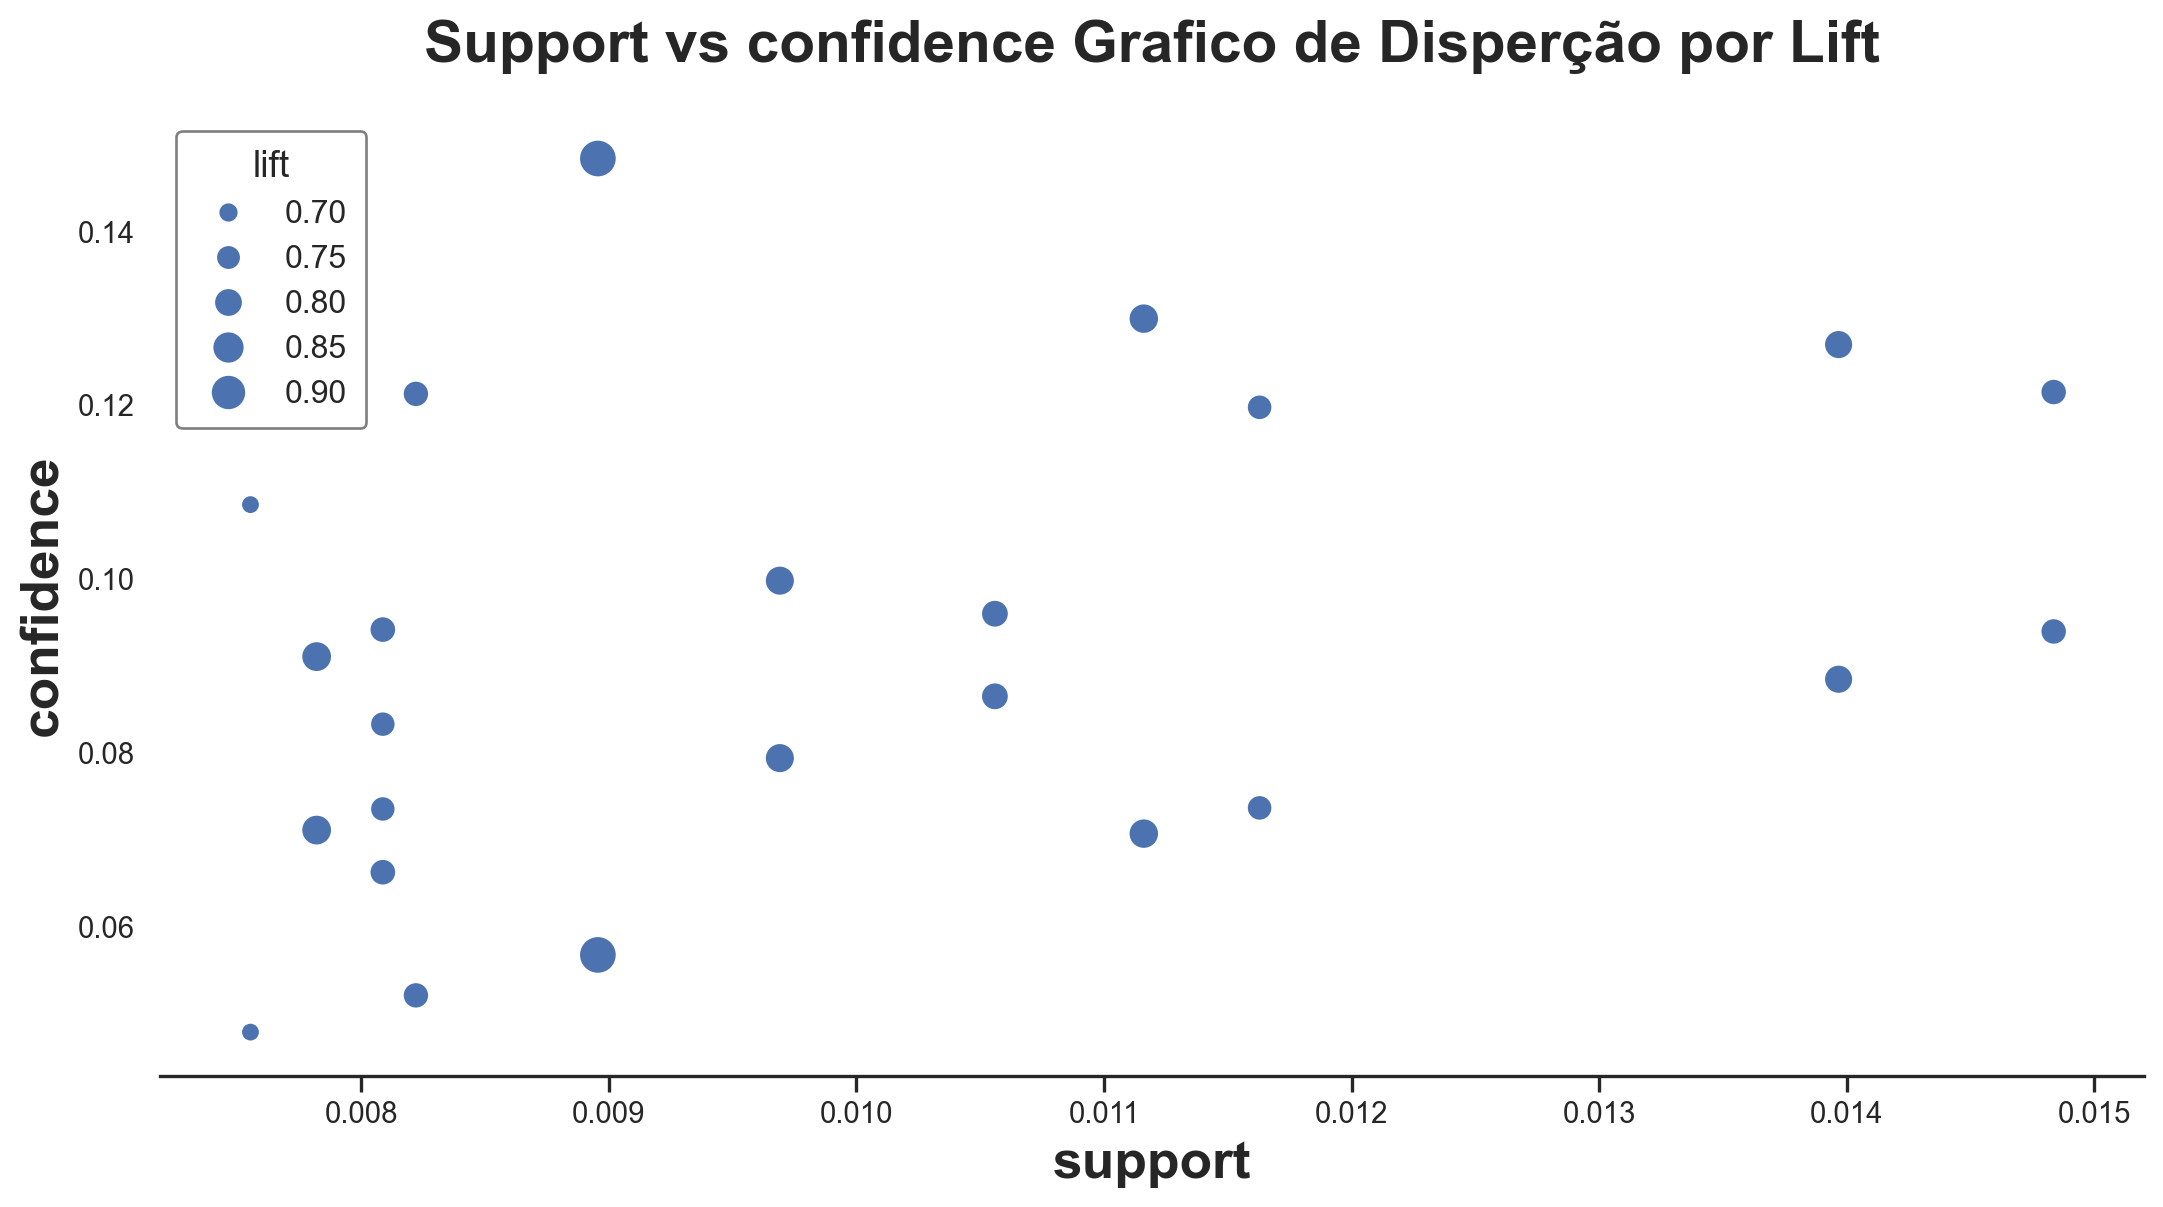

In [ ]:
# Apply the Apriori algorithm with a support value of 0.0075
frequent_itemsets = apriori(onehot, min_support = 0.0075, 
                            use_colnames = True, max_len = 2)

# Generate association rules without performing additional pruning
rules = association_rules(frequent_itemsets, metric = 'support', 
                        min_threshold = 0.0)

# Generate scatterplot using support and confidence
sns.scatterplot(x = "support", y = "confidence", 
                size = "lift",
                hue_norm=None, 
                data = rules)

# Title
plt.title('Support vs confidence Grafico de Disperção por Lift')

plt.show()

>`A região com maiores valores de lift concentra as associações potencialmente mais relevantes do ponto de vista analítico, pois representa combinações cuja coocorrência é superior ao esperado sob independência.`

#### `Coordenadas paralelas`

Esse tipo de gráfico permite comparar simultaneamente múltiplas métricas das regras.

É útil para identificar regras que equilibram frequência, confiabilidade e força associativa.


In [ ]:
# Function to convert rules to coordinates.
def rules_to_coordinates(rules):
    rules['antecedent'] = rules['antecedents'].apply(lambda antecedent: list(antecedent)[0])
    rules['consequent'] = rules['consequents'].apply(lambda consequent: list(consequent)[0])
    rules['rule'] = rules.index
    return rules[['antecedent','consequent','rule']]

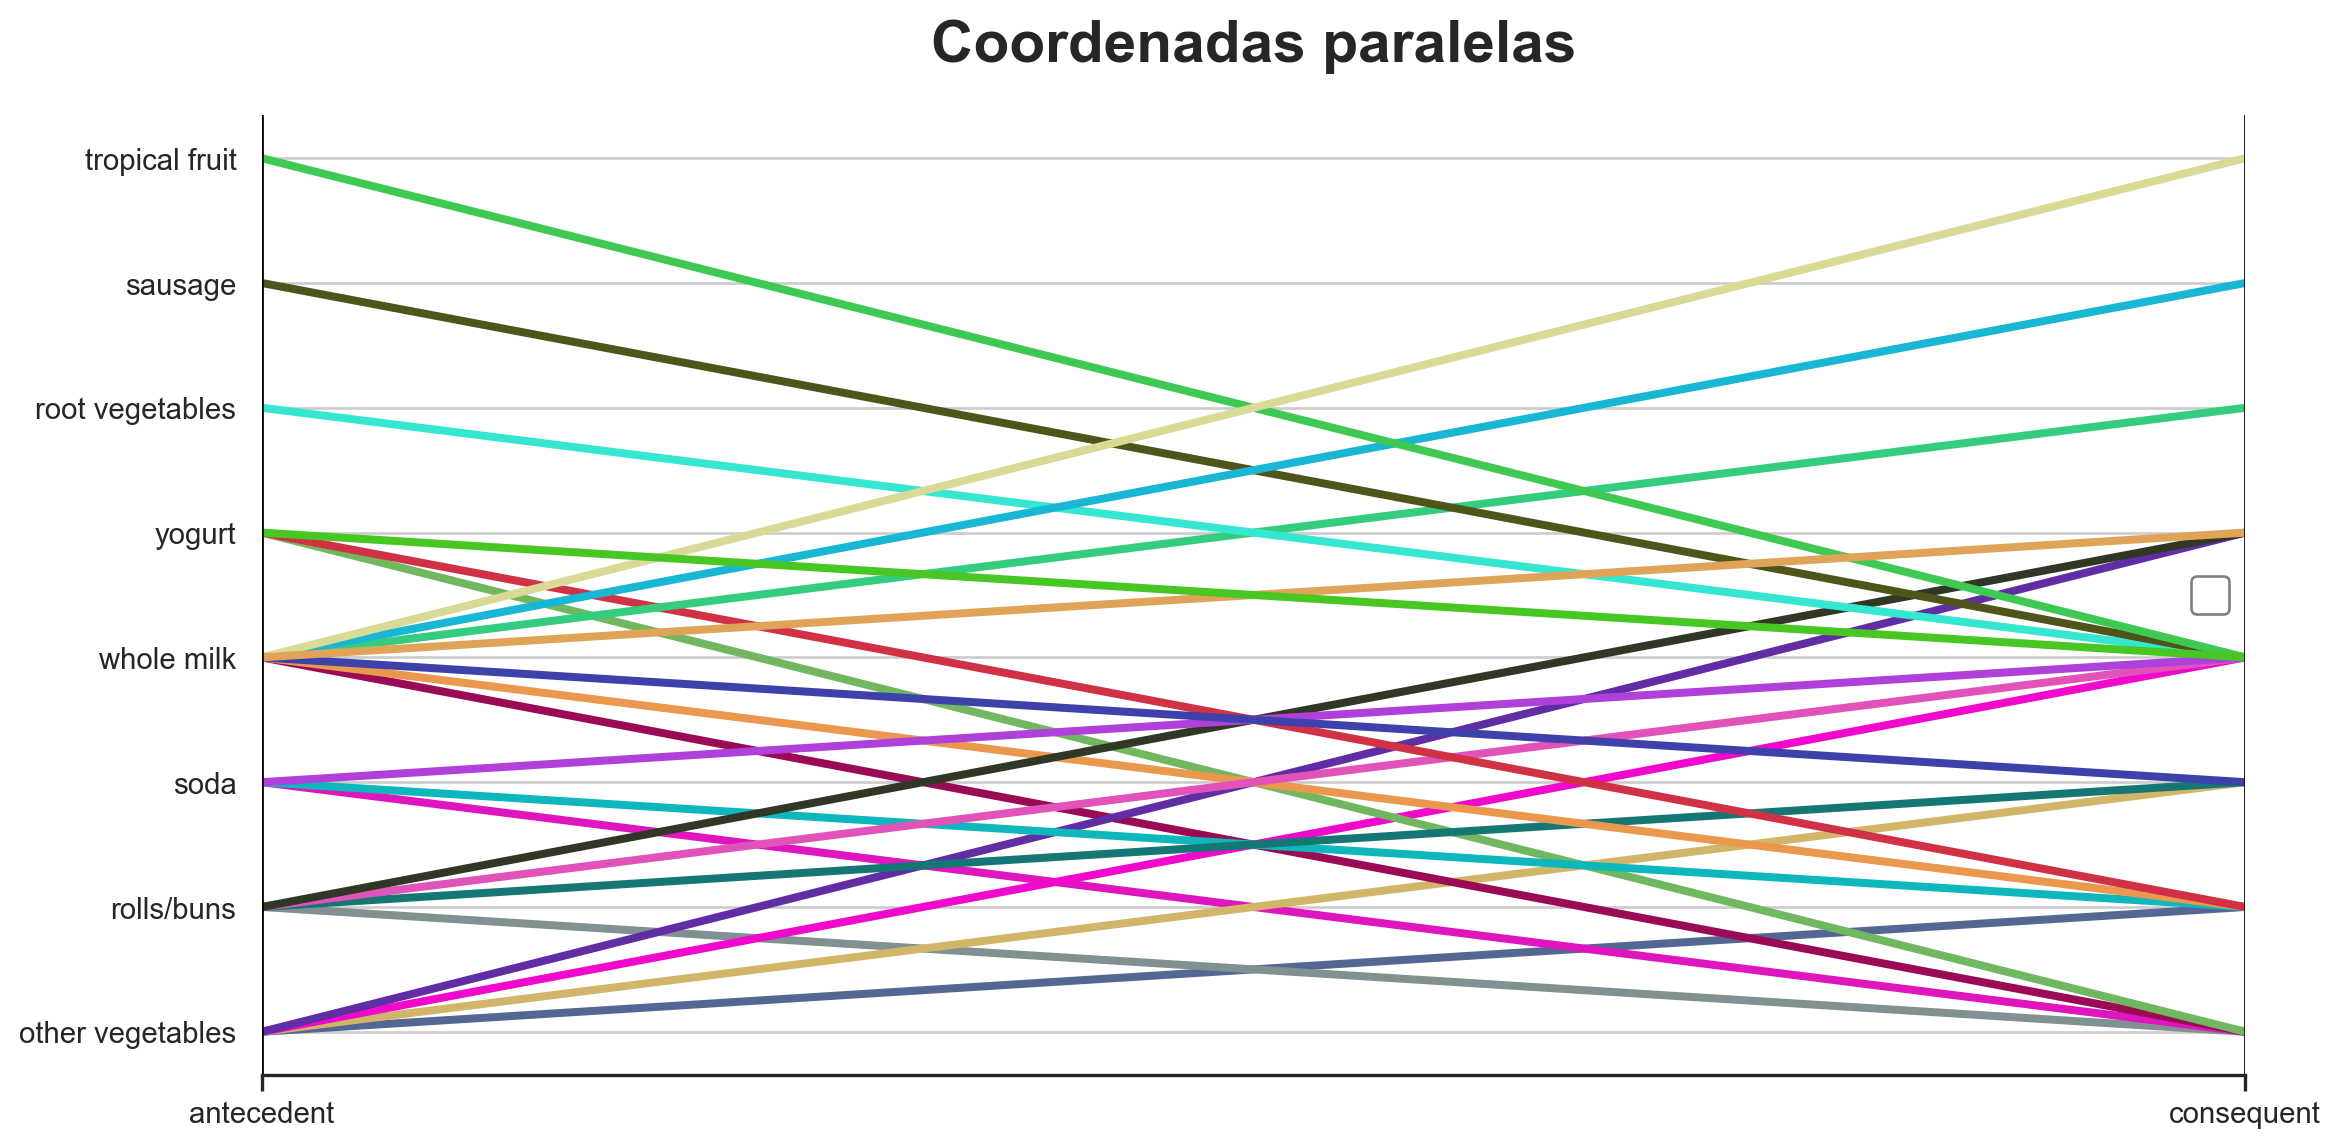

In [ ]:
from pandas.plotting import parallel_coordinates

# Apply the Apriori algorithm with a support value of 0.0075
frequent_itemsets = apriori(onehot, min_support = 0.0075, 
                            use_colnames = True, max_len = 2)

# Generate association rules without performing additional pruning
rules = association_rules(frequent_itemsets, metric = 'support', 
                          min_threshold = 0.0)

# Convert rules into coordinates suitable for use in a parallel coordinates plot
coords = rules_to_coordinates(rules)

# Generate parallel coordinates plot
parallel_coordinates(coords, 'rule')
plt.title('Coordenadas paralelas')
plt.legend([])
plt.show()

### `Conclusão`
A análise mostrou que frequência de compra e força de associação são dimensões diferentes e não devem ser confundidas. Itens amplamente consumidos dominam as métricas de suporte, mas as melhores oportunidades analíticas surgem quando se avaliam conjuntamente suporte, confiança e lift. Em contexto de negócio, a técnica permite apoiar decisões de cross-selling, definição de combos e organização de exposição de produtos, desde que as regras sejam filtradas por relevância estatística e aplicabilidade operacional.